In [1]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code/2_M1_M2_group_level_plots'

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

# Subtlety vs. pf - subject-wise

## subtlety

In [3]:
df_subt = pd.read_csv('../../data/subtlety_playfight_data/subtlety_data.csv',index_col=[0])
df_subt.head()

,subID,block_type,subtlety,chargeSpeeds,responses_subt_1,responses_subt_2,pred_color,responses_pf,RT,movie,trial_num,stim_dur,subt_norm,chargeSpeed_norm,accuracy,responses_pf_rev,chargeSpeed_norm_rev
14,30002,1,90.0,NaN,82.0,grey,grey,NaN,2002.0,06f1dd04-cfbc-433c-9833-32cdb01c0683,14,5692,0.500000,NaN,1.0,NaN,NaN
15,30002,1,30.0,NaN,91.0,grey,grey,NaN,1484.0,57dbdc86-9c49-4214-a908-c4a254e90229,15,5658,0.833333,NaN,1.0,NaN,NaN
16,30002,1,60.0,NaN,79.0,grey,grey,NaN,1774.0,3273fde2-4b65-4cc7-b9b3-ef2604e8a514,16,5645,0.666667,NaN,1.0,NaN,NaN
17,30002,1,90.0,NaN,28.0,black,black,NaN,2049.0,89ce6bb6-b2cb-44cb-ba57-d78ab0224625,17,5669,0.500000,NaN,1.0,NaN,NaN
18,30002,1,90.0,NaN,40.0,grey,grey,NaN,1616.0,7d6cad69-203a-49a4-9c6e-b0423a669e50,18,5620,0.500000,NaN,1.0,NaN,NaN


In [4]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code/2_M1_M2_group_level_plots'

In [5]:
# jitter_strength = .1
subtlety_array = np.unique(df_subt['subtlety'])
subtlety_array

array([  0.,  30.,  60.,  90., 120., 150., 180.])

In [6]:
if df_subt['responses_subt_1'].max() > 1:
    df_subt['responses_subt_1'] /= 100

In [7]:
nsubs = len(np.unique(df_subt['subID']))
nsubs

279

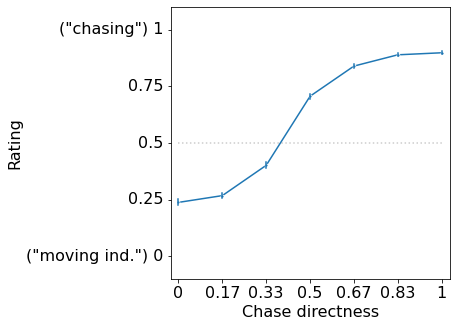

In [8]:
plt.figure(figsize=(5,5))
sns.lineplot(data = df_subt.reset_index(), x = 'subt_norm', y = 'responses_subt_1', marker = '.',   color = 'tab:blue',err_style='bars')
plt.hlines(.5,0,1,ls=':',color = 'grey', alpha = .4)
plt.ylim(-.1,1.1)
plt.yticks(np.arange(0,1.01,.25),['("moving ind.") 0',"0.25","0.5","0.75",'("chasing") 1'],fontsize=16,va='center',ha='right')
plt.xticks(np.unique(df_subt['subt_norm']), [str(np.round(i)).split('.')[0] if i in [0,1] else str(np.round(i,2)) for i in np.unique(df_subt['subt_norm'])],fontsize=16, ha='center')
plt.xlim(-.03,1.03)
plt.ylabel('Rating')
plt.xlabel('Chase directness')

plt.savefig('../../results/subtlety_playfight_mixed/ratings_group_subtletyblocks.png',bbox_inches='tight')

# playfight

In [11]:
df_pf = pd.read_csv('../../data/subtlety_playfight_data/playfight_data.csv',index_col=[0])

In [12]:
# jitter_strength = .1
chargeSpeed_array = np.unique(df_pf['chargeSpeeds'])
chargeSpeed_array

array([1.5 , 2.75, 4.  , 5.25, 6.5 , 7.75, 9.  ])

In [13]:
df_pf['responses_pf'] /= 100

In [14]:
df_pf

,subID,block_type,subtlety,chargeSpeeds,responses_subt_1,responses_subt_2,pred_color,responses_pf,RT,movie,trial_num,stim_dur,subt_norm,chargeSpeed_norm,accuracy,responses_pf_rev,chargeSpeed_norm_rev
6,30002,2,NaN,1.5,NaN,NaN,,0.00,1289.0,e5e05e73-9cd0-4990-8da2-4962e0a03e5d,6,7986,NaN,0.0,NaN,100.0,1.0
32,30002,2,NaN,1.5,NaN,NaN,,0.00,1884.0,8ed7c0fc-1490-4e35-a000-7f7357a0772a,32,8020,NaN,0.0,NaN,100.0,1.0
34,30002,2,NaN,1.5,NaN,NaN,,0.00,1939.0,31e1789e-459a-4f3d-bfdd-2f4c8c4e9f50,34,7948,NaN,0.0,NaN,100.0,1.0
35,30002,2,NaN,1.5,NaN,NaN,,0.00,1869.0,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,35,8033,NaN,0.0,NaN,100.0,1.0
38,30002,2,NaN,1.5,NaN,NaN,,0.01,1464.0,15dfbaca-4429-4c18-90f4-8d4804129e6f,38,7935,NaN,0.0,NaN,99.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,30352,2,NaN,9.0,NaN,NaN,,0.92,1801.0,1be4605b-9f78-45d4-8eb0-87bdc69537e2,28,7991,NaN,1.0,NaN,8.0,0.0
31,30352,2,NaN,9.0,NaN,NaN,,0.85,3493.0,16718611-6bca-4e79-8071-94d68c181ba1,31,8056,NaN,1.0,NaN,15.0,0.0
36,30352,2,NaN,9.0,NaN,NaN,,0.83,1512.0,9f7e489f-4076-4332-b57e-13a42d4c75fd,36,8073,NaN,1.0,NaN,17.0,0.0
57,30352,2,NaN,9.0,NaN,NaN,,0.70,2427.0,8649b489-429a-4894-9c74-827e94f04566,57,8082,NaN,1.0,NaN,30.0,0.0


In [15]:
xspace = .03*(9-1.5) # 3% room on either sides of the lowest and highest xticks to match with the detection task
xspace

0.22499999999999998

In [16]:
1.5-xspace, 9+xspace

(1.275, 9.225)

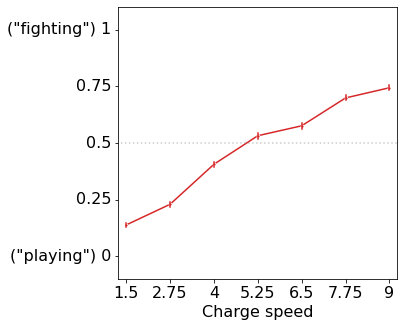

In [17]:
plt.figure(figsize=(5,5))
sns.lineplot(data = df_pf.reset_index(),x = 'chargeSpeeds',y = 'responses_pf',  marker = '.', color = 'tab:red', err_style='bars')
plt.ylim(-.1,1.1)
plt.hlines(.5,1,9.5,ls=':',color = 'grey', alpha = .4)
plt.ylabel('')
plt.xlabel('Charge speed')
plt.xticks(chargeSpeed_array, ["1.5","2.75","4","5.25","6.5","7.75","9"],fontsize=16, ha='center')
plt.yticks(np.arange(0,1.01,.25),['("playing") 0',"0.25","0.5","0.75",'("fighting") 1'],fontsize=16,va='center',ha='right')
plt.xlim(1.275,9.225)
plt.savefig('../../results/subtlety_playfight_mixed/ratings_group_pfblocks.png',bbox_inches='tight')